In [ ]:
#!/bin/bash
!kaggle datasets download mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 31.1MB/s]



In [ ]:
!unzip insurance.zip

Archive:  insurance.zip
  inflating: insurance.csv           


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
# Analyze the dataset structure, data types, descriptive statistics, missing values, and duplicate records.
# Data Visualization: Visualize the numerical features using Histograms, Boxplots, Scatter Plots.
# Outlier Detection: Detect outliers using the IQR and Z-Score methods, provide the corresponding formulas, and compare the results.
# Outlier Analysis: Evaluate the impact of outliers and justify whether they should be removed or retained.
# Feature Scaling: Apply StandardScaler, MinMaxScaler and briefly explain their purposes and differences.
# Conclusion: Summarize the key findings and identify the most appropriate scaling method for the dataset.

In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.reset_index(inplace=True, drop=True)

In [ ]:
df.shape

(1337, 7)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
sns.set()

In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


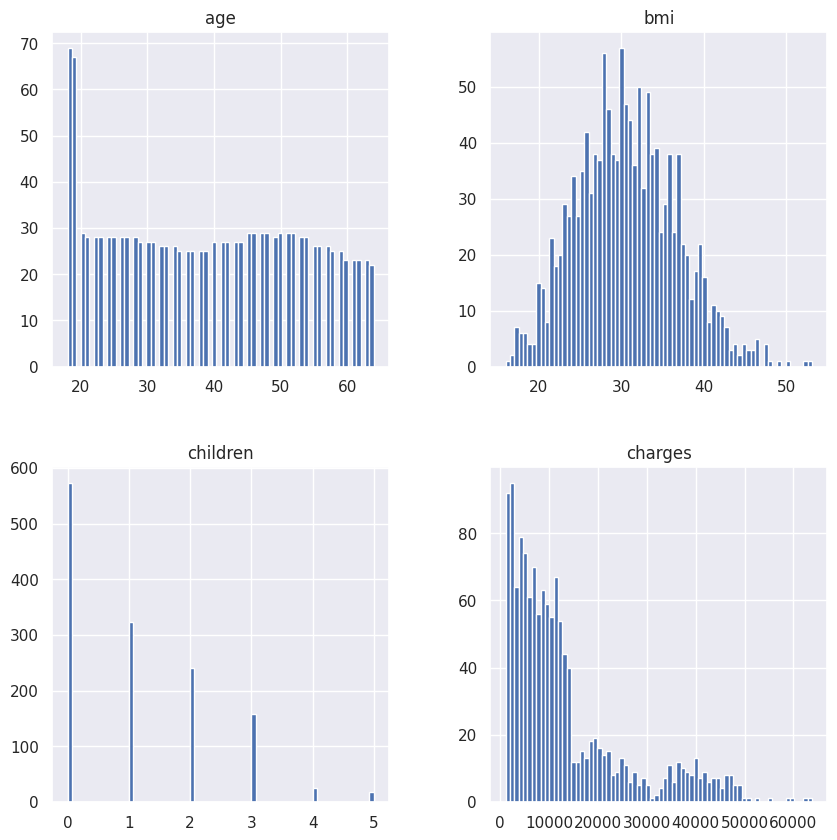

In [ ]:
df.hist(figsize=(10,10),bins=70);

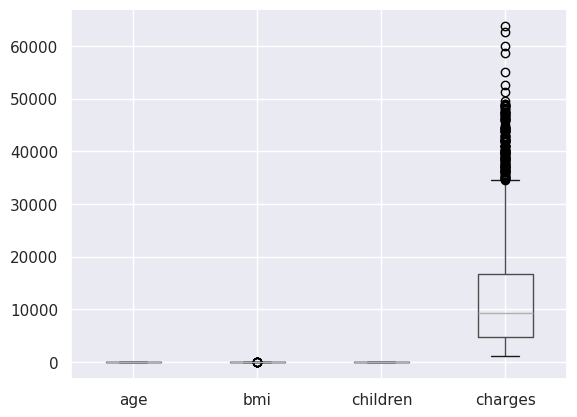

In [ ]:
df.boxplot();

In [ ]:
columns=['age','bmi','children','charges']

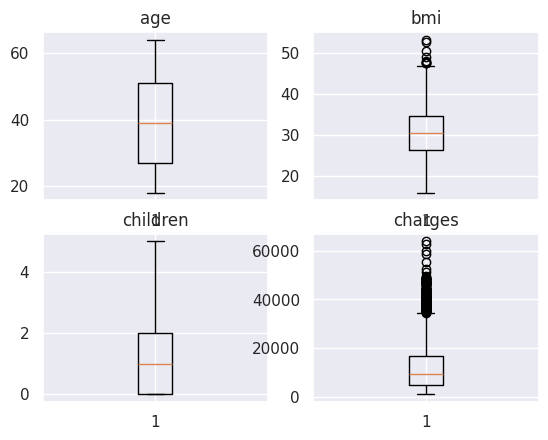

In [ ]:
fig,axs = plt.subplots(2,2)
for i in range (2):
  for j in range (2):
    axs[i,j].boxplot(df[columns[i*2+j]])
    axs[i,j].set_title(columns[i*2+j])

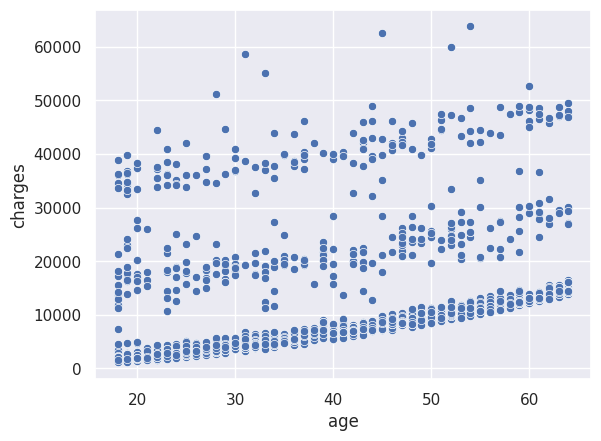

In [ ]:
sns.scatterplot(df, x='age',y='charges');

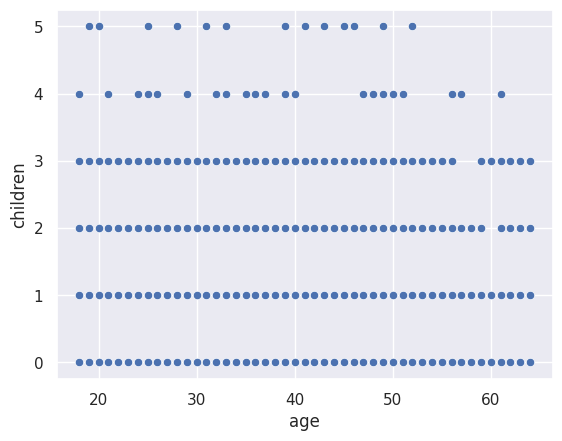

In [ ]:
sns.scatterplot(df, x='age',y='children');

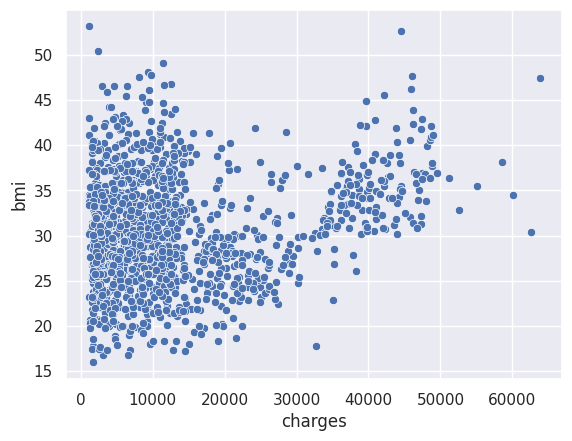

In [ ]:
sns.scatterplot(df, x='charges',y='bmi');

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
X = df.drop('charges',axis=1)
y =  df['charges']

In [ ]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [ ]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1332,10600.54830
1333,2205.98080
1334,1629.83350
1335,2007.94500


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline ([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

num_cols= ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

In [ ]:
from sklearn.compose import ColumnTransformer

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])
full_pipeline.fit_transform(X_train)

array([[-1.1576804 , -0.99692768, -0.90790804, ...,  0.        ,
         0.        ,  0.        ],
       [-1.30061876, -0.79276204,  0.7669042 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.91492586,  1.15466402,  0.7669042 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-1.37208794, -1.4118716 , -0.07050192, ...,  0.        ,
         0.        ,  1.        ],
       [-0.08564268, -0.41997378,  1.60431032, ...,  0.        ,
         0.        ,  1.        ],
       [-0.30005022,  0.87941237,  0.7669042 , ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
from sklearn.linear_model import LinearRegression

reg_pipeline = Pipeline([
	('temizleme', full_pipeline),
	('modelleme', LinearRegression())
])
reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('temizleme',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('modelleme', LinearRegression())])

In [ ]:
y_pred = reg_pipeline.predict(X_test)
y_pred

array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
        8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
        1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
        3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
        4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
        3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
        3.11077668e+04,  5.51196081e+03,  3.55030401e+04,  3.65704810e+04,
        1.14123133e+04,  1.42056990e+04,  6.50234029e+03,  1.27246945e+04,
        3.99806590e+02,  1.20883980e+04,  3.96592069e+04,  1.23395540e+04,
        4.74412279e+03,  3.91903157e+03,  3.08606789e+04,  8.95870663e+03,
        7.05389441e+03,  3.01125636e+04,  3.47804324e+04,  1.22916189e+04,
        7.35739310e+03,  3.42060530e+03,  6.21243471e+03,  8.98345200e+03,
        4.26401828e+03,  9.01992870e+03,  6.60149578e+03,  1.20802337e+04,
        3.12447687e+04,  

In [ ]:
y_test.to_numpy()

array([ 8688.85885 ,  5708.867   , 11436.73815 , 38746.3551  ,
        4463.2051  ,  9304.7019  , 38511.6283  ,  2150.469   ,
        7345.7266  , 10264.4421  , 13415.0381  , 24393.6224  ,
       37607.5277  , 13063.883   , 24915.04626 ,  8027.968   ,
        1980.07    , 38709.176   ,  3484.331   ,  3947.4131  ,
        1880.07    , 20773.62775 ,  9800.8882  , 21082.16    ,
       55135.40209 ,  3579.8287  , 43896.3763  , 52590.82939 ,
        9778.3472  , 10736.87075 ,  4347.02335 ,  9048.0273  ,
        1711.0268  , 12333.828   , 63770.42801 ,  9872.701   ,
        4687.797   ,  5693.4305  , 21195.818   ,  8233.0975  ,
        2755.02095 , 19798.05455 , 42124.5153  ,  9964.06    ,
        9193.8385  ,  3161.454   ,  2217.6012  ,  7337.748   ,
        4133.64165 ,  6338.0756  ,  4349.462   ,  5757.41345 ,
       21771.3423  ,  1391.5287  ,  7160.094   ,  7731.4271  ,
        9957.7216  ,  3594.17085 , 38282.7495  ,  7256.7231  ,
       10977.2063  ,  5245.2269  , 11187.6567  ,  1708.

In [ ]:
np.abs(y_pred - y_test.to_numpy()).mean()

np.float64(4177.045561036322)

In [ ]:
y.mean()

np.float64(13279.121486655948)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
	('temizleme', full_pipeline),
	('modelleme', RandomForestRegressor())
])
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
y_pred

array([10514.6170502,  6196.8697154, 12806.4895599, 43746.457369 ,
        5824.9186191, 10194.9804301, 39037.5744437,  2199.6397815,
        8468.3745558, 11077.0025466, 14237.2188585, 24164.4340627,
       43801.1166363, 15653.6751786,  6802.1278201,  9142.2011072,
       10900.426401 , 39515.202244 ,  4771.4817227,  5813.344202 ,
        9097.9033421, 20823.1148563, 10411.9631776, 20477.7994817,
       38738.7986693, 19156.6239875, 43723.9978016, 45934.813805 ,
       11465.6378414, 14728.0652304,  4188.9945172,  9746.8929155,
        2979.8543588, 14675.0327508, 47386.3094343,  9731.07004  ,
        7201.670228 ,  5674.7899206, 22922.8413615,  8372.765977 ,
        3574.812914 , 21644.5233285, 41406.4579768,  9840.3910162,
        9533.80009  ,  3972.8967232,  3435.290031 ,  7760.7842386,
        6444.6137826, 12808.3549172,  4568.8570108,  8391.0000205,
       22643.8783541,  5726.6242956,  7354.6807948,  8519.4611439,
       11908.5634506,  6720.2363589, 40729.638737 ,  7711.4351

In [ ]:
np.abs(y_pred - y_test.to_numpy()).mean()

np.float64(2620.8106985123127)